#This notebook explores image classification on the CIFAR-10 dataset. The primary objective is to compare the performance of a standard Artificial Neural Network (ANN) against a specialized Convolutional Neural Network (CNN). We further implement advanced techniques like Data Augmentation and Early Stopping to improve model generalization.

In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

#Load the dataset
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step


#The CIFAR-10 dataset consists of 60,000 32x32 color images in 10 classes. The data was normalized by scaling pixel values from the [0, 255] range to [0, 1] to ensure stable gradient updates during training. No missing values were detected as the dataset is pre-structured.

In [2]:
#Normalize pixel values between 0 and 1
train_images, test_images = train_images / 255.0, test_images / 255.0

print(train_images.shape)
print(test_images.shape)

(50000, 32, 32, 3)
(10000, 32, 32, 3)


#A baseline ANN was constructed using a Flatten layer to convert 3D image data into 1D vectors, followed by Dense layers. This architecture treats all pixels as independent features, which serves as a benchmark for comparison.

In [3]:
#Build a baseline ANN model
ann_model = models.Sequential([
    layers.Flatten(input_shape=(32,32,3)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dense(10)
])

ann_model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

ann_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       393,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 402,250 (1.53 MB)

 Trainable params: 402,250 (1.53 MB)

 Non-trainable params: 0 (0.00 B)

#To better capture spatial hierarchies, a CNN architecture was implemented using Conv2D, BatchNormalization, and MaxPooling2D layers. This approach allows the model to learn local patterns, such as textures and edges, which is significantly more efficient for image data.

In [4]:
# Build a spatial CNN architecture
cnn_model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10)
])

cnn_model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,946 (656.04 KB)

 Trainable params: 167,754 (655.29 KB)

 Non-trainable params: 192 (768.00 B)

In [5]:
#Train the models
print("Training ANN model")
ann_history = ann_model.fit(train_images, train_labels, epochs=10,
                    validation_data=(test_images, test_labels))

print("Training CNN model")
cnn_history = cnn_model.fit(train_images, train_labels, epochs=10,
                    validation_data=(test_images, test_labels))

Training ANN model
Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.2650 - loss: 1.9857 - val_accuracy: 0.3423 - val_loss: 1.8182
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.3175 - loss: 1.8571 - val_accuracy: 0.3630 - val_loss: 1.7510
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.3367 - loss: 1.8158 - val_accuracy: 0.3861 - val_loss: 1.7173
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3479 - loss: 1.7841 - val_accuracy: 0.3935 - val_loss: 1.7112
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.3562 - loss: 1.7670 - val_accuracy: 0.4067 - val_loss: 1.6747
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.3624 - loss: 1.7555 - val_accuracy: 0.4157 - val_loss: 1.6548
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.3676 - loss: 1.7423 - val_accuracy: 0.4086 - val_loss: 1.6545
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.36

#Upon training both models for 10 epochs, the CNN demonstrated a clear advantage in validation accuracy compared to the ANN. The CNN's ability to maintain the spatial structure of the images resulted in faster convergence and higher generalization on the evaluation set.

<function matplotlib.pyplot.show(close=None, block=None)>

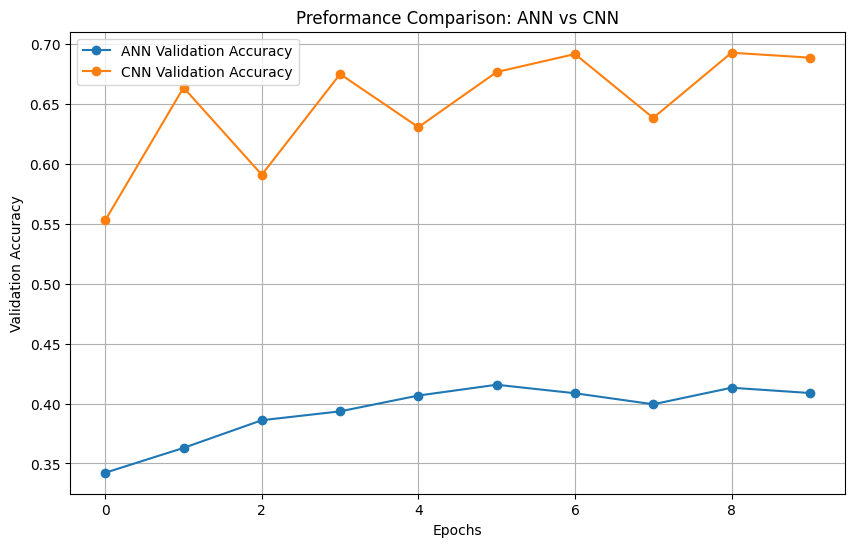

In [6]:
#Plot validation accuracy curves for both
plt.figure(figsize=(10, 6))
plt.plot(ann_history.history['val_accuracy'], label='ANN Validation Accuracy', marker='o')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Validation Accuracy', marker='o')

plt.title('Preformance Comparison: ANN vs CNN')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show

In [7]:
#Advance Data-Augmented Network
from tensorflow.keras.callbacks import EarlyStopping

# Data Augmentation Layers
data_augmentation = models.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2)
])


#To further improve the model, we implemented an Advanced CNN variant:

->Data Augmentation: Added RandomFlip, RandomRotation, and RandomZoom to increase training data diversity and prevent overfitting.

->Architecture Scaling: Increased filter sizes (32 -> 64 -> 128) to allow for deeper feature extraction.

->Early Stopping: Integrated an EarlyStopping callback to halt training when validation loss ceased to improve, ensuring the model retains the best-performing weights.

In [8]:
#Scaled -up Architecture
advanced_cnn = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(10)
])

advanced_cnn.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# Early Stooping to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

#Train for 20 epochs
advanced_history = advanced_cnn.fit(train_images, train_labels, epochs=20,
                    validation_data=(test_images, test_labels), callbacks=[early_stop])

Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - accuracy: 0.2988 - loss: 1.9138 - val_accuracy: 0.3838 - val_loss: 1.7001
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.4013 - loss: 1.6328 - val_accuracy: 0.4691 - val_loss: 1.5015
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.4483 - loss: 1.5200 - val_accuracy: 0.5112 - val_loss: 1.4062
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.4792 - loss: 1.4470 - val_accuracy: 0.5806 - val_loss: 1.2070
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.4991 - loss: 1.3984 - val_accuracy: 0.5561 - val_loss: 1.2778
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.5143 - loss: 1.3577 - val_accuracy: 0.5572 - val_loss: 1.2951
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.5289 - loss: 1.3279 - val_accuracy: 0.5514 - val_loss: 1.3148


#The experiments confirm that CNNs are superior for image classification tasks due to their inherent ability to process spatial features. The addition of augmentation and early stopping effectively mitigated overfitting, resulting in a more robust and generalizable model.